In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import sys # Import sys module

# 1. Load Data
try:
    df = pd.read_csv('/content/drive/MyDrive/smart_mobility_dataset.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Please upload 'smart_mobility_dataset.csv' to the Colab Files tab.")
    sys.exit("Stopping execution.") # Exit if file not found

# 2. Data Cleaning & Feature Engineering
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour_of_Day'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek

# --- NEW: FILTER FOR 7 DAYS (March 1st to March 7th) ---
start_date = '2024-03-01'
end_date = '2024-03-07' # 7th is included
mask = (df['Timestamp'] >= start_date) & (df['Timestamp'] <= end_date)
df_filtered = df.loc[mask]

print(f"Filtered Data: {len(df_filtered)} rows found between {start_date} and {end_date}")
# -------------------------------------------------------

# 3. Define Features and Target (Using the Filtered Data)
features = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Hour_of_Day', 'Day_of_Week']
target = 'Traffic_Condition'

X = df_filtered[features]
y = df_filtered[target]

# 4. Train Model
print("Training Random Forest Model on 7-Day Data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Check Accuracy
accuracy = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Model Training Complete. Accuracy: {accuracy*100:.2f}%")

# 6. Save
joblib.dump(rf_model, 'traffic_brain.pkl')
# We also save the filtered data so the simulation can use "Real" rows instead of random ones
joblib.dump(df_filtered, 'traffic_data_7days.pkl')
print("SUCCESS: Model and 7-Day Data saved.")

Dataset loaded successfully.
Filtered Data: 1729 rows found between 2024-03-01 and 2024-03-07
Training Random Forest Model on 7-Day Data...
Model Training Complete. Accuracy: 96.24%
SUCCESS: Model and 7-Day Data saved.


In [ ]:
import joblib
import pandas as pd
import time

# 1. Load Model AND Real Data
print("Loading AI Model and 7-Day Dataset...")
try:
    model = joblib.load('traffic_brain.pkl')
    # Load the real data we saved in Step 1
    real_traffic_data = joblib.load('traffic_data_7days.pkl')
    print("Model and Data loaded successfully!")
except FileNotFoundError:
    print("Error: Files not found. Run Step 1 again.")

feature_columns = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Hour_of_Day', 'Day_of_Week']

def control_traffic_light(prediction):
    if prediction == 'High':
        return "RED ALERT: High Congestion -> Green Light EXTENDED (60s)"
    elif prediction == 'Medium':
        return "Standard Flow: Medium Congestion -> Green Light NORMAL (30s)"
    else:
        return "Road Clear: Low Congestion -> Green Light SHORT (10s)"

print("\n--- AI TRAFFIC CONTROLLER STARTED (Simulation: March 1 - March 7) ---")
print("Replaying Historical Traffic Events...\n")

# --- NEW: LOOP THROUGH REAL DATA ---
# We simulate the FIRST 10 events from your 7-day week to demonstrate functionality.
# You can change .head(10) to .sample(10) if you want random moments from that week.
for index, row in real_traffic_data.head(2017).iterrows():

    # 1. Get Inputs (From Real History, not Random)
    # We strip the data to just the features the model needs
    live_input = row[feature_columns].to_frame().T

    # 2. Predict (Think)
    predicted_congestion = model.predict(live_input)[0]

    # 3. Act
    decision = control_traffic_light(predicted_congestion)

    # 4. Visual Output
    timestamp_str = row['Timestamp'].strftime('%Y-%m-%d %H:%M:%S')
    print(f"Date: {timestamp_str} | Traffic: {row['Vehicle_Count']} cars, {row['Traffic_Speed_kmh']} km/h")
    print(f"AI Prediction: {predicted_congestion}")
    print(f"System Action: {decision}")
    print("-" * 60)

    time.sleep(1) # Fast forward simulation

Streaming output truncated to the last 5000 lines.
Date: 2024-03-02 15:55:00 | Traffic: 48 cars, 69.80575193708823 km/h
AI Prediction: Low
System Action: Road Clear: Low Congestion -> Green Light SHORT (10s)
------------------------------------------------------------
Date: 2024-03-02 16:00:00 | Traffic: 118 cars, 5.440155755958807 km/h
AI Prediction: High
System Action: RED ALERT: High Congestion -> Green Light EXTENDED (60s)
------------------------------------------------------------
Date: 2024-03-02 16:05:00 | Traffic: 153 cars, 68.941734321137 km/h
AI Prediction: Medium
System Action: Standard Flow: Medium Congestion -> Green Light NORMAL (30s)
------------------------------------------------------------
Date: 2024-03-02 16:10:00 | Traffic: 188 cars, 75.69054987914906 km/h
AI Prediction: Medium
System Action: Standard Flow: Medium Congestion -> Green Light NORMAL (30s)
------------------------------------------------------------
Date: 2024-03-02 16:15:00 | Traffic: 188 cars, 50.61

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import sys

# 1. Load Data with a Safety Check
print("Attempting to load dataset...")
try:
    df = pd.read_csv('/content/drive/MyDrive/smart_mobility_dataset.csv')
    print("SUCCESS: Dataset loaded.")
except FileNotFoundError:
    print("\n!!! ERROR: File not found !!!")
    print("Please upload 'smart_mobility_dataset.csv' to the Colab Files tab.")
    sys.exit("Stopping execution.")

# 2. Data Cleaning
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour_of_Day'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek

# 3. Filter for March 1st - March 7th
start_date = '2024-03-01'
end_date = '2024-03-07'
mask = (df['Timestamp'] >= start_date) & (df['Timestamp'] <= end_date)
df_filtered = df.loc[mask]

print(f"Filtered Data: {len(df_filtered)} rows found between {start_date} and {end_date}")

# 4. Train Model
features = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Hour_of_Day', 'Day_of_Week']
target = 'Traffic_Condition'

X = df_filtered[features]
y = df_filtered[target]

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y) # Train on full filtered set for the demo

# 5. SAVE THE FILES (Crucial Step)
joblib.dump(rf_model, 'traffic_brain.pkl')
joblib.dump(df_filtered, 'traffic_data_7days.pkl')
print("SUCCESS: Model and 7-Day Data saved.")

Attempting to load dataset...
SUCCESS: Dataset loaded.
Filtered Data: 1729 rows found between 2024-03-01 and 2024-03-07
SUCCESS: Model and 7-Day Data saved.


✅ Recovery Successful: 'df_filtered' loaded with 1729 rows.


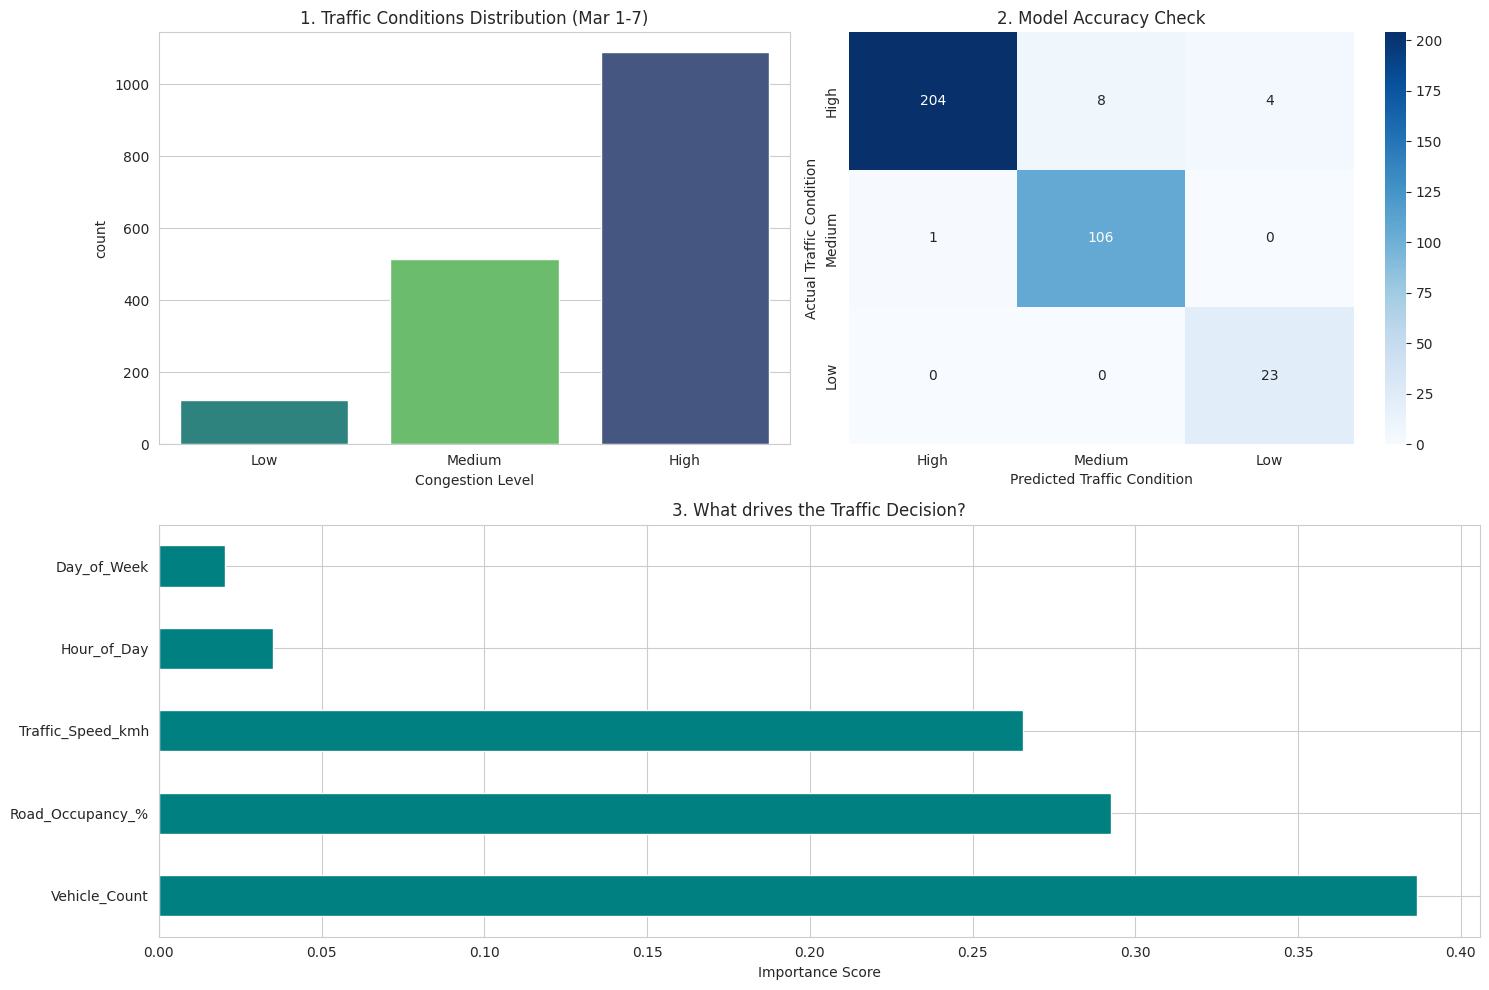

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# --- STEP 1: FIX THE MISSING VARIABLE (Re-load & Filter) ---
try:
    # 1. Load Data
    df = pd.read_csv('/content/drive/MyDrive/smart_mobility_dataset.csv')

    # 2. Data Cleaning & Feature Engineering
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour_of_Day'] = df['Timestamp'].dt.hour
    df['Day_of_Week'] = df['Timestamp'].dt.dayofweek

    # 3. Re-create df_filtered (The missing part)
    start_date = '2024-03-01'
    end_date = '2024-03-07'
    mask = (df['Timestamp'] >= start_date) & (df['Timestamp'] <= end_date)
    df_filtered = df.loc[mask]
    print(f"✅ Recovery Successful: 'df_filtered' loaded with {len(df_filtered)} rows.")

except FileNotFoundError:
    print("❌ Error: Dataset not found. Please mount drive or upload the CSV.")

# --- STEP 2: RE-TRAIN MODEL (Briefly, for the charts) ---
features = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Hour_of_Day', 'Day_of_Week']
target = 'Traffic_Condition'
X = df_filtered[features]
y = df_filtered[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- STEP 3: GENERATE VISUALIZATIONS ---
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10)) # Make the whole figure larger

# Chart A: Data Distribution (The Input)
plt.subplot(2, 2, 1)
sns.countplot(x=df_filtered['Traffic_Condition'],
              hue=df_filtered['Traffic_Condition'],  # <--- Added this
              palette='viridis',
              order=['Low', 'Medium', 'High'],
              legend=False)                          # <--- Added this
plt.title('1. Traffic Conditions Distribution (Mar 1-7)', fontsize=12)
plt.xlabel('Congestion Level')

# Chart B: Confusion Matrix (The Accuracy) - FIXED ORDER
plt.subplot(2, 2, 2)

# 1. Define the logical order we want
class_order = ['High', 'Medium', 'Low']

# 2. Generate matrix using this specific order
cm = confusion_matrix(y_test, rf_model.predict(X_test), labels=class_order)

# 3. Plot it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order)

plt.title('2. Model Accuracy Check', fontsize=12)
plt.xlabel('Predicted Traffic Condition')
plt.ylabel('Actual Traffic Condition')

# Chart C: Feature Importance (The Logic)
plt.subplot(2, 1, 2) # This one takes the whole bottom row
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('3. What drives the Traffic Decision?', fontsize=12)
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd
import time
import sys

# 1. Load the files created in Step 1
print("Loading AI Model and 7-Day Dataset...")
try:
    model = joblib.load('traffic_brain.pkl')
    real_traffic_data = joblib.load('traffic_data_7days.pkl')
    print("Model and Data loaded successfully!")
except FileNotFoundError:
    print("\n!!! ERROR: Files not found !!!")
    print("You MUST run Step 1 first to create the 'pkl' files.")
    sys.exit("Stopping execution.")

feature_columns = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Hour_of_Day', 'Day_of_Week']

def control_traffic_light(prediction):
    if prediction == 'High':
        return "RED ALERT: High Congestion -> Green Light EXTENDED (60s)"
    elif prediction == 'Medium':
        return "Standard Flow: Medium Congestion -> Green Light NORMAL (30s)"
    else:
        return "Road Clear: Low Congestion -> Green Light SHORT (10s)"

print("\n--- AI TRAFFIC CONTROLLER STARTED (Simulation: March 1 - March 7) ---")

# 2. Run Loop on Real Data
# We select 5 random moments from that week to show variety
sample_data = real_traffic_data.sample(5)

for index, row in sample_data.iterrows():
    live_input = row[feature_columns].to_frame().T

    predicted_congestion = model.predict(live_input)[0]
    decision = control_traffic_light(predicted_congestion)

    print(f"Date: {row['Timestamp']} | Traffic: {row['Vehicle_Count']} cars, {row['Traffic_Speed_kmh']} km/h")
    print(f"AI Prediction: {predicted_congestion}")
    print(f"System Action: {decision}")
    print("-" * 60)

    time.sleep(1)

Loading AI Model and 7-Day Dataset...
Model and Data loaded successfully!

--- AI TRAFFIC CONTROLLER STARTED (Simulation: March 1 - March 7) ---
Date: 2024-03-05 02:25:00 | Traffic: 74 cars, 75.38320425471572 km/h
AI Prediction: Low
System Action: Road Clear: Low Congestion -> Green Light SHORT (10s)
------------------------------------------------------------
Date: 2024-03-01 23:05:00 | Traffic: 99 cars, 46.64542710081032 km/h
AI Prediction: Medium
System Action: Standard Flow: Medium Congestion -> Green Light NORMAL (30s)
------------------------------------------------------------
Date: 2024-03-02 18:25:00 | Traffic: 104 cars, 78.7632348805527 km/h
AI Prediction: Medium
System Action: Standard Flow: Medium Congestion -> Green Light NORMAL (30s)
------------------------------------------------------------
Date: 2024-03-02 20:30:00 | Traffic: 156 cars, 30.012810374840488 km/h
AI Prediction: Medium
System Action: Standard Flow: Medium Congestion -> Green Light NORMAL (30s)
------------